# Segmentación de Clientes — Rumbo Verde
**Período:** Enero 2025 – Abril 2026  
**Fuente:** Jumpseller (canal ecommerce)  
**Objetivo:** Clasificar la base de clientes en 3 grupos según 
su comportamiento de compra y definir una estrategia de 
comunicación personalizada para cada uno.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

VERDE  = '#2D7A4F'
AZUL   = '#2563EB'
NARANJ = '#F59E0B'
ROJO   = '#EF4444'
GRIS   = '#94A3B8'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.linestyle'   : '--',
    'figure.facecolor' : '#FAFAFA',
    'axes.facecolor'   : '#FAFAFA',
})

print("✅ Librerías listas")

✅ Librerías listas


In [2]:
# ─────────────────────────────────────────────────
# PASO 1 — Cargar y limpiar datos Jumpseller
# ─────────────────────────────────────────────────

# Cargamos los dos archivos y los unimos en uno solo
# igual que hicimos con Bsale en el notebook anterior
js25 = pd.read_csv('../data/pedidos_2025.csv', sep=';')
js26 = pd.read_csv('../data/pedidos_2026.csv', sep=';')
js   = pd.concat([js25, js26], ignore_index=True)

# Filtramos solo pedidos pagados
# Los cancelados o pendientes no representan clientes reales
js_pagados = js[js['Estado del Pago'] == 'Pagado'].copy()

# Limpiamos el monto total
# Jumpseller usa coma como separador decimal — hay que convertirlo
js_pagados['Total_num'] = pd.to_numeric(
    js_pagados['Total'].astype(str).str.replace(',', '.').str.strip(),
    errors='coerce'
)

# Convertimos la fecha
js_pagados['fecha_dt'] = pd.to_datetime(js_pagados['Fecha'].str[:10])

# Un pedido puede tener varias filas (una por producto)
# Agrupamos por ID de pedido para tener una fila por compra
pedidos = js_pagados.groupby('ID').agg(
    email      = ('Email', 'first'),
    fecha      = ('fecha_dt', 'first'),
    total      = ('Total_num', 'first'),
    ciudad     = ('Ciudad de Envío', 'first'),
).reset_index()

print(f"✅ Pedidos pagados:      {len(pedidos):,}")
print(f"✅ Clientes únicos:      {pedidos['email'].nunique():,}")
print(f"✅ Período:              {pedidos['fecha'].min().date()} → {pedidos['fecha'].max().date()}")
print(f"✅ Ticket promedio:      ${pedidos['total'].mean():,.0f} CLP")
print(f"✅ Venta total período:  ${pedidos['total'].sum()/1e6:.2f}M CLP")

✅ Pedidos pagados:      5,237
✅ Clientes únicos:      4,225
✅ Período:              2025-01-01 → 2026-04-30
✅ Ticket promedio:      $41,894 CLP
✅ Venta total período:  $219.40M CLP


In [3]:
# ─────────────────────────────────────────────────
# PASO 2 — Calcular RFM y segmentar clientes
# ─────────────────────────────────────────────────

# Fecha de referencia = último día del período analizado
# Así calculamos cuántos días hace que cada cliente compró
fecha_ref = pedidos['fecha'].max()

# Agrupamos por cliente para calcular los 3 indicadores RFM
# R = Recencia:   días desde la última compra
# F = Frecuencia: cantidad de pedidos
# M = Monto:      gasto total acumulado
rfm = pedidos.groupby('email').agg(
    ultima_compra = ('fecha', 'max'),
    frecuencia    = ('ID', 'count'),
    monto_total   = ('total', 'sum')
).reset_index()

# Calculamos recencia en días
# Mientras menos días = cliente más reciente = más valioso
rfm['recencia_dias'] = (fecha_ref - rfm['ultima_compra']).dt.days

# ── Clasificación en 3 grupos ──
# Usamos la recencia como criterio principal
# porque es el indicador más directo de riesgo de pérdida

def clasificar_cliente(dias):
    if dias <= 60:
        return 'Activo'        # compró en los últimos 2 meses
    elif dias <= 120:
        return 'En riesgo'     # lleva 2 a 4 meses sin comprar
    else:
        return 'Inactivo'      # más de 4 meses sin comprar

rfm['segmento'] = rfm['recencia_dias'].apply(clasificar_cliente)

# Resumen por segmento
resumen = rfm.groupby('segmento').agg(
    clientes      = ('email', 'count'),
    recencia_prom = ('recencia_dias', 'mean'),
    frecuencia    = ('frecuencia', 'mean'),
    gasto_prom    = ('monto_total', 'mean'),
    gasto_total   = ('monto_total', 'sum')
).reset_index()
resumen['% base']      = (resumen['clientes'] / resumen['clientes'].sum() * 100).round(1)
resumen['gasto_prom']  = resumen['gasto_prom'].round(0)
resumen['gasto_total_M'] = (resumen['gasto_total'] / 1e6).round(2)
resumen['recencia_prom'] = resumen['recencia_prom'].round(0)
resumen['frecuencia']    = resumen['frecuencia'].round(2)

print("=== SEGMENTACIÓN DE CLIENTES ===")
print(resumen[['segmento','clientes','% base','recencia_prom',
               'frecuencia','gasto_prom','gasto_total_M']].to_string(index=False))
print()
print(f"Fecha de referencia: {fecha_ref.date()}")

=== SEGMENTACIÓN DE CLIENTES ===
 segmento  clientes  % base  recencia_prom  frecuencia  gasto_prom  gasto_total_M
   Activo       910    21.5           30.0        1.45     61062.0          55.57
En riesgo       527    12.5           88.0        1.22     47497.0          25.03
 Inactivo      2788    66.0          301.0        1.18     49786.0         138.80

Fecha de referencia: 2026-04-30


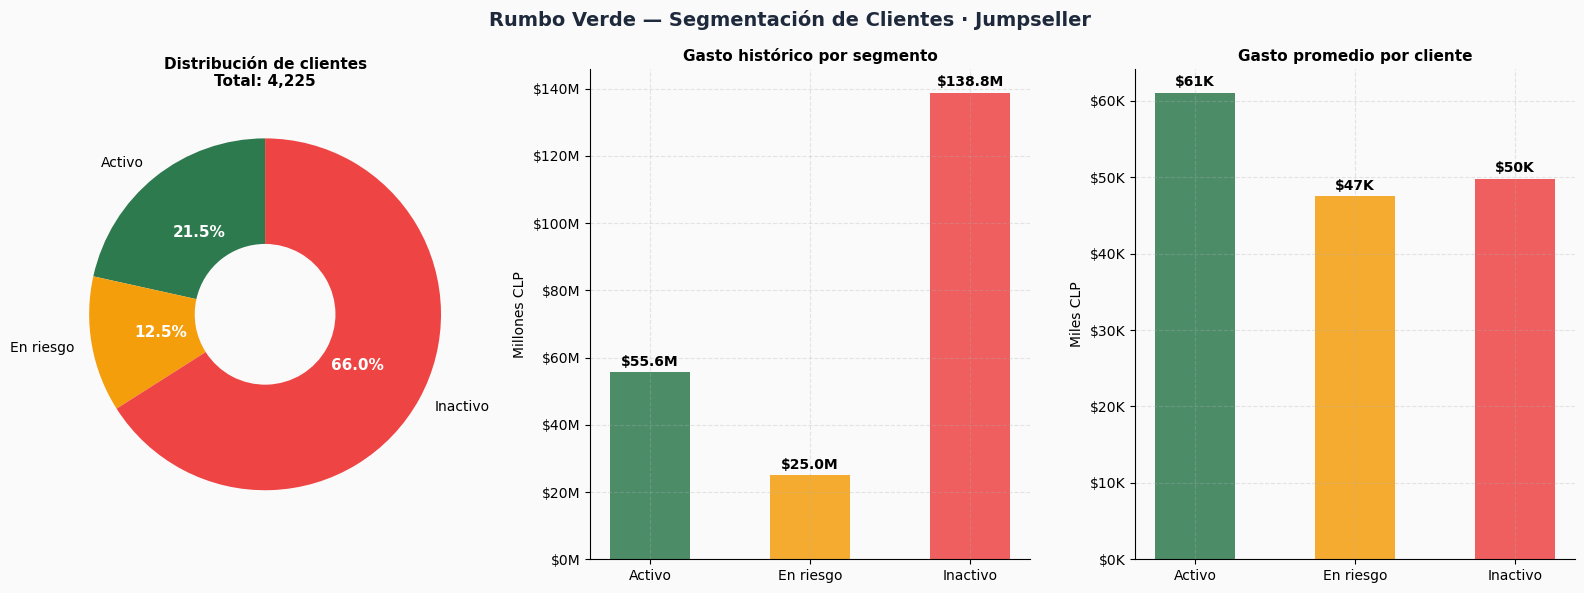

✅ Gráfico guardado en outputs/


In [4]:
# ─────────────────────────────────────────────────
# PASO 3 — Visualizar la segmentación
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Rumbo Verde — Segmentación de Clientes · Jumpseller',
             fontsize=14, fontweight='bold', color='#1E293B')

orden    = ['Activo', 'En riesgo', 'Inactivo']
colores  = [VERDE, NARANJ, ROJO]
resumen  = resumen.set_index('segmento').reindex(orden).reset_index()

# ── Gráfico 1: Distribución de clientes ──
ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    resumen['clientes'],
    labels=resumen['segmento'],
    colors=colores,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6),
    textprops=dict(fontsize=10)
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')
    at.set_color('white')
ax1.set_title(f'Distribución de clientes\nTotal: {resumen["clientes"].sum():,}',
              fontsize=11, fontweight='bold')

# ── Gráfico 2: Gasto total por segmento ──
ax2 = axes[1]
barras = ax2.bar(resumen['segmento'], resumen['gasto_total_M'],
                 color=colores, alpha=0.85, width=0.5)
ax2.set_title('Gasto histórico por segmento', fontsize=11, fontweight='bold')
ax2.set_ylabel('Millones CLP', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
for bar in barras:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+1,
             f'${h:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Gráfico 3: Gasto promedio por cliente ──
ax3 = axes[2]
barras3 = ax3.bar(resumen['segmento'], resumen['gasto_prom']/1000,
                  color=colores, alpha=0.85, width=0.5)
ax3.set_title('Gasto promedio por cliente', fontsize=11, fontweight='bold')
ax3.set_ylabel('Miles CLP', fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}K'))
for bar in barras3:
    h = bar.get_height()
    ax3.text(bar.get_x()+bar.get_width()/2, h+0.5,
             f'${h:.0f}K', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/rv_segmentacion_clientes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en outputs/")

In [5]:
# ─────────────────────────────────────────────────
# PASO 4 — Estrategia de comunicación por segmento
# ─────────────────────────────────────────────────

# Para cada segmento definimos:
# - El objetivo de la comunicación
# - El mensaje central
# - La rutina de bienestar sugerida
# - La frecuencia de contacto

estrategias = {
    'Activo': {
        'objetivo'   : 'Fidelizar y subir el ticket',
        'mensaje'    : 'Gracias por elegirnos — te recomendamos esto según lo que compraste',
        'accion'     : 'Email mensual con rutina complementaria a su última compra',
        'rutina'     : 'Personalizada según último producto comprado',
        'frecuencia' : 'Una vez al mes',
        'meta'       : 'Subir frecuencia de compra de 1,45 a 2 pedidos por cliente',
        'clientes'   : 910,
        'potencial'  : 910 * 61062 * 0.30  # 30% sube ticket un 20%
    },
    'En riesgo': {
        'objetivo'   : 'Reactivar antes de que se vuelvan inactivos',
        'mensaje'    : 'Te echamos de menos — tenemos algo especial para ti',
        'accion'     : 'Email de reactivación con rutina relacionada a su historial',
        'rutina'     : 'La rutina más vendida del mes + beneficio exclusivo',
        'frecuencia' : 'Una vez por semana durante 3 semanas',
        'meta'       : 'Reactivar el 30% del segmento (158 clientes)',
        'clientes'   : 527,
        'potencial'  : 527 * 0.30 * 47497  # 30% reactivación
    },
    'Inactivo': {
        'objetivo'   : 'Recuperar los más recientes del grupo',
        'mensaje'    : '¿Cómo estás? Han pasado algunos meses — queremos saber cómo te sentiste',
        'accion'     : 'Email de reconexión emocional + testimonio de cliente similar',
        'rutina'     : 'Rutina Anti-Estrés o Defensas según temporada',
        'frecuencia' : 'Una vez al mes durante 2 meses',
        'meta'       : 'Reactivar el 10% del segmento (279 clientes)',
        'clientes'   : 2788,
        'potencial'  : 2788 * 0.10 * 49786  # 10% reactivación
    }
}

print("=" * 65)
print("  ESTRATEGIA DE COMUNICACIÓN POR SEGMENTO")
print("=" * 65)

total_potencial = 0
for segmento, datos in estrategias.items():
    print(f"\n{'🟢' if segmento=='Activo' else '🟡' if segmento=='En riesgo' else '🔴'} {segmento.upper()} — {datos['clientes']:,} clientes")
    print(f"  Objetivo:    {datos['objetivo']}")
    print(f"  Mensaje:     {datos['mensaje']}")
    print(f"  Acción:      {datos['accion']}")
    print(f"  Rutina:      {datos['rutina']}")
    print(f"  Frecuencia:  {datos['frecuencia']}")
    print(f"  Meta:        {datos['meta']}")
    print(f"  Potencial:   ${datos['potencial']/1e6:.2f}M CLP")
    total_potencial += datos['potencial']

print(f"\n{'='*65}")
print(f"  POTENCIAL TOTAL DE RECUPERACIÓN: ${total_potencial/1e6:.2f}M CLP")
print(f"{'='*65}")

  ESTRATEGIA DE COMUNICACIÓN POR SEGMENTO

🟢 ACTIVO — 910 clientes
  Objetivo:    Fidelizar y subir el ticket
  Mensaje:     Gracias por elegirnos — te recomendamos esto según lo que compraste
  Acción:      Email mensual con rutina complementaria a su última compra
  Rutina:      Personalizada según último producto comprado
  Frecuencia:  Una vez al mes
  Meta:        Subir frecuencia de compra de 1,45 a 2 pedidos por cliente
  Potencial:   $16.67M CLP

🟡 EN RIESGO — 527 clientes
  Objetivo:    Reactivar antes de que se vuelvan inactivos
  Mensaje:     Te echamos de menos — tenemos algo especial para ti
  Acción:      Email de reactivación con rutina relacionada a su historial
  Rutina:      La rutina más vendida del mes + beneficio exclusivo
  Frecuencia:  Una vez por semana durante 3 semanas
  Meta:        Reactivar el 30% del segmento (158 clientes)
  Potencial:   $7.51M CLP

🔴 INACTIVO — 2,788 clientes
  Objetivo:    Recuperar los más recientes del grupo
  Mensaje:     ¿Cómo estás

In [6]:
# ─────────────────────────────────────────────────
# PASO 5 — Templates de email por segmento
# ─────────────────────────────────────────────────

# Estos son los mensajes reales que se enviarían
# a cada segmento. Están escritos en el tono de
# Rumbo Verde — cercano, experto y sin descuentos

emails = {

    'Activo': {
        'asunto': '🌿 Cris, esto complementa lo que compraste',
        'cuerpo': """
Hola [Nombre],

Gracias por ser parte de la comunidad Rumbo Verde.

Revisamos tu última compra y tenemos una sugerencia que
puede potenciar aún más los resultados que estás buscando.

Si compraste Neuromag PRO, el siguiente paso natural es
agregar Vitamina D3+K2 — juntos trabajan mejor para el
sistema nervioso y la calidad del sueño.

Esta es la Rutina Energía Mental completa:
→ Neuromag PRO 90 cáps
→ Vitamina D3 + K2 60 cáps
→ GoldenMaqui 60 cáps

Nuestro equipo está disponible para orientarte
si tienes dudas sobre cómo tomar cada producto.

Cuídate,
Equipo Rumbo Verde
        """
    },

    'En riesgo': {
        'asunto': '💚 [Nombre], hace un tiempo que no sabemos de ti',
        'cuerpo': """
Hola [Nombre],

Hace algunos meses que no te vemos por aquí y
queríamos saber cómo estás.

¿Lograste los resultados que buscabas con
tu última compra? Nos importa saberlo.

Este mes estamos especialmente enfocados en
la Rutina Anti-Estrés — una de las más pedidas
por nuestra comunidad:

→ Neuromag PRO (sistema nervioso)
→ B Complex Liposomal (equilibrio mental)
→ Ashwagandha (adaptógeno natural)

Si tienes alguna consulta sobre tu bienestar,
nuestro equipo está aquí para orientarte
sin compromiso.

Con cariño,
Equipo Rumbo Verde
        """
    },

    'Inactivo': {
        'asunto': '🌱 Han pasado algunos meses, [Nombre]',
        'cuerpo': """
Hola [Nombre],

Han pasado varios meses desde tu última visita
a Rumbo Verde y queríamos escribirte.

Sabemos que el camino hacia el bienestar
no siempre es lineal — a veces se necesita
un empujón o simplemente alguien que
te oriente en el siguiente paso.

Una de nuestras clientas, María, llegó
con problemas de sueño hace 8 meses.
Hoy nos escribe para contarnos que duerme
mejor que nunca con la Rutina Sueño Reparador.

Si alguna vez quieres retomar tu camino
hacia el bienestar, aquí estamos.
Sin presión, solo con ganas de ayudarte.

Cuídate mucho,
Equipo Rumbo Verde

PD: Si tienes una consulta específica sobre
tu salud, puedes responder este email y
te orientamos personalmente.
        """
    }
}

for segmento, email in emails.items():
    icono = '🟢' if segmento=='Activo' else '🟡' if segmento=='En riesgo' else '🔴'
    print(f"{icono} EMAIL — SEGMENTO {segmento.upper()}")
    print(f"Asunto: {email['asunto']}")
    print(f"{'─'*55}")
    print(email['cuerpo'])
    print(f"{'='*55}\n")

🟢 EMAIL — SEGMENTO ACTIVO
Asunto: 🌿 Cris, esto complementa lo que compraste
───────────────────────────────────────────────────────

Hola [Nombre],

Gracias por ser parte de la comunidad Rumbo Verde.

Revisamos tu última compra y tenemos una sugerencia que
puede potenciar aún más los resultados que estás buscando.

Si compraste Neuromag PRO, el siguiente paso natural es
agregar Vitamina D3+K2 — juntos trabajan mejor para el
sistema nervioso y la calidad del sueño.

Esta es la Rutina Energía Mental completa:
→ Neuromag PRO 90 cáps
→ Vitamina D3 + K2 60 cáps
→ GoldenMaqui 60 cáps

Nuestro equipo está disponible para orientarte
si tienes dudas sobre cómo tomar cada producto.

Cuídate,
Equipo Rumbo Verde
        

🟡 EMAIL — SEGMENTO EN RIESGO
Asunto: 💚 [Nombre], hace un tiempo que no sabemos de ti
───────────────────────────────────────────────────────

Hola [Nombre],

Hace algunos meses que no te vemos por aquí y
queríamos saber cómo estás.

¿Lograste los resultados que buscabas con
tu úl

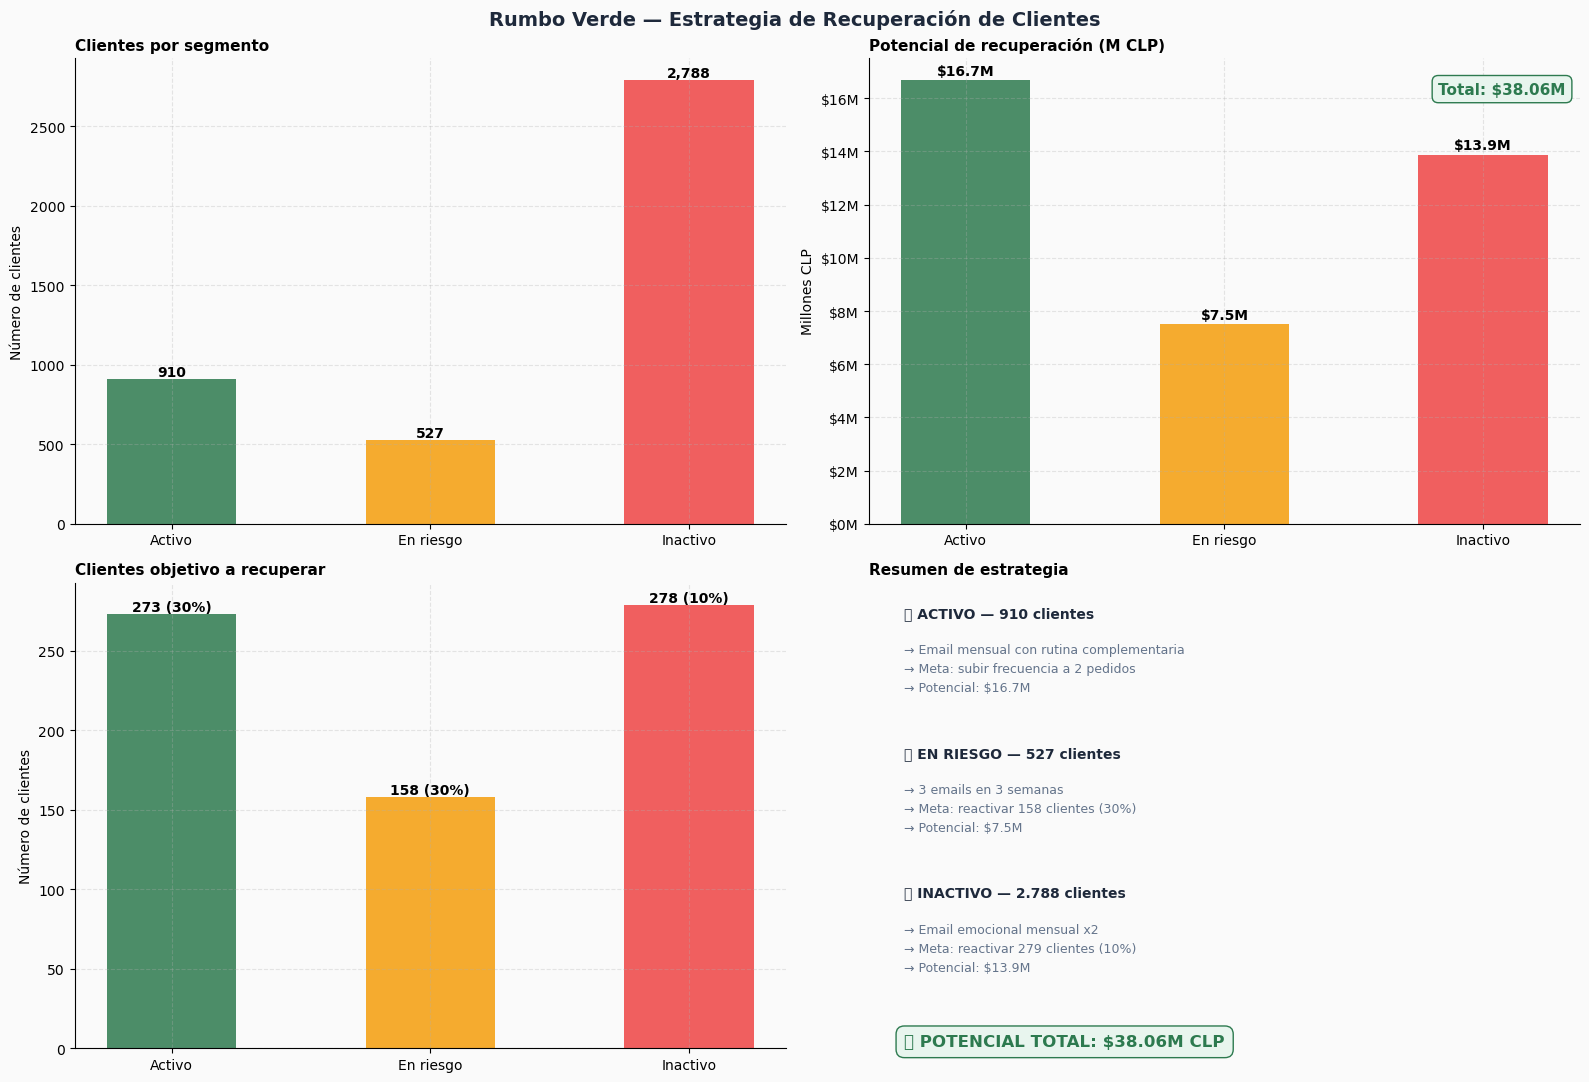

✅ Gráfico guardado en outputs/


In [8]:
# ─────────────────────────────────────────────────
# PASO 6 — Gráfico resumen estrategia por segmento
# ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Rumbo Verde — Estrategia de Recuperación de Clientes',
             fontsize=14, fontweight='bold', color='#1E293B')

orden   = ['Activo', 'En riesgo', 'Inactivo']
colores = [VERDE, NARANJ, ROJO]
counts  = [910, 527, 2788]
gastos  = [55.57, 25.03, 138.80]
potenc  = [16.67, 7.51, 13.88]
metas   = [910*0.30, 527*0.30, 2788*0.10]

# ── Gráfico 1: Clientes por segmento ──
ax1 = axes[0, 0]
barras1 = ax1.bar(orden, counts, color=colores, alpha=0.85, width=0.5)
ax1.set_title('Clientes por segmento', fontsize=11, fontweight='bold', loc='left')
ax1.set_ylabel('Número de clientes', fontsize=10)
for bar, val in zip(barras1, counts):
    ax1.text(bar.get_x()+bar.get_width()/2, val+20,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# ── Gráfico 2: Potencial de recuperación ──
ax2 = axes[0, 1]
barras2 = ax2.bar(orden, potenc, color=colores, alpha=0.85, width=0.5)
ax2.set_title('Potencial de recuperación (M CLP)', fontsize=11, fontweight='bold', loc='left')
ax2.set_ylabel('Millones CLP', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:.0f}M'))
for bar, val in zip(barras2, potenc):
    ax2.text(bar.get_x()+bar.get_width()/2, val+0.2,
             f'${val:.1f}M', ha='center', fontsize=10, fontweight='bold')

# Total potencial
ax2.text(0.98, 0.95, f'Total: $38.06M',
         transform=ax2.transAxes, ha='right', va='top',
         fontsize=11, fontweight='bold', color=VERDE,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#E8F5EE', edgecolor=VERDE))

# ── Gráfico 3: Clientes a recuperar por meta ──
ax3 = axes[1, 0]
barras3 = ax3.bar(orden, metas, color=colores, alpha=0.85, width=0.5)
ax3.set_title('Clientes objetivo a recuperar', fontsize=11, fontweight='bold', loc='left')
ax3.set_ylabel('Número de clientes', fontsize=10)
pcts = ['30%', '30%', '10%']
for bar, val, pct in zip(barras3, metas, pcts):
    ax3.text(bar.get_x()+bar.get_width()/2, val+2,
             f'{int(val)} ({pct})', ha='center', fontsize=10, fontweight='bold')

# ── Gráfico 4: Resumen estrategia ──
ax4 = axes[1, 1]
ax4.axis('off')

estrategia_texto = [
    ('🟢 ACTIVO — 910 clientes',
     '→ Email mensual con rutina complementaria\n→ Meta: subir frecuencia a 2 pedidos\n→ Potencial: $16.7M'),
    ('🟡 EN RIESGO — 527 clientes',
     '→ 3 emails en 3 semanas\n→ Meta: reactivar 158 clientes (30%)\n→ Potencial: $7.5M'),
    ('🔴 INACTIVO — 2.788 clientes',
     '→ Email emocional mensual x2\n→ Meta: reactivar 279 clientes (10%)\n→ Potencial: $13.9M'),
]

y = 0.95
for titulo, detalle in estrategia_texto:
    ax4.text(0.05, y, titulo, transform=ax4.transAxes,
             fontsize=10, fontweight='bold', color='#1E293B', va='top')
    y -= 0.08
    ax4.text(0.05, y, detalle, transform=ax4.transAxes,
             fontsize=9, color='#64748B', va='top', linespacing=1.6)
    y -= 0.22

ax4.text(0.05, y-0.02,
         '💰 POTENCIAL TOTAL: $38.06M CLP',
         transform=ax4.transAxes,
         fontsize=12, fontweight='bold', color=VERDE, va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#E8F5EE', edgecolor=VERDE))

ax4.set_title('Resumen de estrategia', fontsize=11, fontweight='bold', loc='left')

plt.tight_layout()
plt.savefig('../outputs/rv_estrategia_segmentos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en outputs/")

In [9]:
# ─────────────────────────────────────────────────
# PASO 7 — Exportar listas por segmento
# ─────────────────────────────────────────────────

# Enriquecemos el RFM con el último producto comprado
# Eso permite personalizar cada email con lo que
# realmente compró el cliente — no un mensaje genérico

ultimo_producto = js_pagados.sort_values('fecha_dt').groupby('Email').last()[['Nombre del Producto']].reset_index()
ultimo_producto.columns = ['email', 'ultimo_producto']

# Unimos con el RFM
rfm_completo = rfm.merge(ultimo_producto, on='email', how='left')

# Agregamos ciudad para posibles acciones locales
ciudad = pedidos.groupby('email')['ciudad'].first().reset_index()
rfm_completo = rfm_completo.merge(ciudad, on='email', how='left')

# Seleccionamos columnas relevantes y ordenamos
rfm_completo = rfm_completo[[
    'email', 'segmento', 'recencia_dias', 'frecuencia',
    'monto_total', 'ultima_compra', 'ultimo_producto', 'ciudad'
]].sort_values(['segmento', 'recencia_dias'])

# Exportamos una hoja por segmento
with pd.ExcelWriter('../outputs/rv_clientes_segmentados.xlsx', engine='openpyxl') as writer:

    # Hoja resumen
    resumen_export = rfm_completo.groupby('segmento').agg(
        clientes      = ('email', 'count'),
        recencia_prom = ('recencia_dias', 'mean'),
        frecuencia    = ('frecuencia', 'mean'),
        gasto_prom    = ('monto_total', 'mean'),
        gasto_total   = ('monto_total', 'sum')
    ).reset_index()
    resumen_export.to_excel(writer, sheet_name='Resumen', index=False)

    # Una hoja por segmento
    for segmento in ['Activo', 'En riesgo', 'Inactivo']:
        df_seg = rfm_completo[rfm_completo['segmento'] == segmento].copy()
        df_seg.columns = ['Email', 'Segmento', 'Días sin comprar', 'Nº compras',
                          'Gasto total CLP', 'Última compra', 'Último producto', 'Ciudad']
        df_seg.to_excel(writer, sheet_name=segmento, index=False)

print("✅ Archivo Excel exportado: rv_clientes_segmentados.xlsx")
print()
print("=== CONTENIDO DEL ARCHIVO ===")
print(f"  Hoja 'Resumen':    Vista general de los 3 segmentos")
print(f"  Hoja 'Activo':     {len(rfm_completo[rfm_completo['segmento']=='Activo']):,} clientes listos para fidelizar")
print(f"  Hoja 'En riesgo':  {len(rfm_completo[rfm_completo['segmento']=='En riesgo']):,} clientes prioritarios para reactivar")
print(f"  Hoja 'Inactivo':   {len(rfm_completo[rfm_completo['segmento']=='Inactivo']):,} clientes para campaña de reconexión")
print()
print("=== MUESTRA SEGMENTO EN RIESGO ===")
muestra = rfm_completo[rfm_completo['segmento']=='En riesgo'][
    ['email','recencia_dias','frecuencia','monto_total','ultimo_producto']
].head(5)
muestra.columns = ['Email','Días sin comprar','Nº compras','Gasto total','Último producto']
print(muestra.to_string(index=False))

✅ Archivo Excel exportado: rv_clientes_segmentados.xlsx

=== CONTENIDO DEL ARCHIVO ===
  Hoja 'Resumen':    Vista general de los 3 segmentos
  Hoja 'Activo':     910 clientes listos para fidelizar
  Hoja 'En riesgo':  527 clientes prioritarios para reactivar
  Hoja 'Inactivo':   2,788 clientes para campaña de reconexión

=== MUESTRA SEGMENTO EN RIESGO ===
                                            Email  Días sin comprar  Nº compras  Gasto total                                          Último producto
                           belenpineira@gmail.com                61           1      23890.0           Wellplus - Magnesio Butirato Pure 60 capsulas 
       calu1122623@jumpseller-mercadolibreapp.com                61           1     167118.0 Colágeno Hidrolizado Proteínas + Vitaminas 435g Giovegen
       caropaola94@jumpseller-mercadolibreapp.com                61           1      33525.0                      Eunoe - Night Time Performance 90c 
               cecilia.jimenez.orellana@gm

In [10]:
# ─────────────────────────────────────────────────
# PASO 8 — Limpiar emails no contactables
# ─────────────────────────────────────────────────

# Algunos clientes compraron a través de MercadoLibre
# Sus emails son generados automáticamente y no son reales
# No tiene sentido incluirlos en campañas de email

# Identificamos emails no contactables
no_contactable = rfm_completo['email'].str.contains(
    'jumpseller|mercadolibre|noreply|no-reply',
    case=False, na=False
)

rfm_contactable     = rfm_completo[~no_contactable].copy()
rfm_no_contactable  = rfm_completo[no_contactable].copy()

print("=== CALIDAD DE LA BASE DE CONTACTOS ===")
print(f"Total clientes:              {len(rfm_completo):,}")
print(f"Emails contactables:         {len(rfm_contactable):,}")
print(f"Emails NO contactables (ML): {len(rfm_no_contactable):,}")
print(f"% contactable:               {len(rfm_contactable)/len(rfm_completo)*100:.1f}%")
print()
print("=== SEGMENTACIÓN REAL (solo contactables) ===")
seg_real = rfm_contactable.groupby('segmento').agg(
    clientes    = ('email', 'count'),
    gasto_prom  = ('monto_total', 'mean'),
    gasto_total = ('monto_total', 'sum')
).reset_index()
seg_real['gasto_prom']    = seg_real['gasto_prom'].round(0)
seg_real['gasto_total_M'] = (seg_real['gasto_total']/1e6).round(2)
seg_real['pct_base']      = (seg_real['clientes']/seg_real['clientes'].sum()*100).round(1)
print(seg_real[['segmento','clientes','pct_base','gasto_prom','gasto_total_M']].to_string(index=False))
print()

# Reexportar Excel limpio
with pd.ExcelWriter('../outputs/rv_clientes_segmentados_limpio.xlsx', engine='openpyxl') as writer:
    resumen_export = seg_real.copy()
    resumen_export.to_excel(writer, sheet_name='Resumen', index=False)
    for segmento in ['Activo', 'En riesgo', 'Inactivo']:
        df_seg = rfm_contactable[rfm_contactable['segmento']==segmento].copy()
        df_seg.columns = ['Email','Segmento','Días sin comprar','Nº compras',
                          'Gasto total CLP','Última compra','Último producto','Ciudad']
        df_seg.to_excel(writer, sheet_name=segmento, index=False)

print("✅ Excel limpio exportado: rv_clientes_segmentados_limpio.xlsx")

=== CALIDAD DE LA BASE DE CONTACTOS ===
Total clientes:              4,225
Emails contactables:         3,207
Emails NO contactables (ML): 1,018
% contactable:               75.9%

=== SEGMENTACIÓN REAL (solo contactables) ===
 segmento  clientes  pct_base  gasto_prom  gasto_total_M
   Activo       560      17.5     76249.0          42.70
En riesgo       352      11.0     54318.0          19.12
 Inactivo      2295      71.6     53322.0         122.38

✅ Excel limpio exportado: rv_clientes_segmentados_limpio.xlsx


In [11]:
# ─────────────────────────────────────────────────
# RESUMEN FINAL — Notebook 03
# ─────────────────────────────────────────────────

total_contactable = 560 + 352 + 2295

print("=" * 60)
print("  RESUMEN — SEGMENTACIÓN DE CLIENTES RUMBO VERDE")
print("=" * 60)
print(f"  Base total Jumpseller:        {4225:,} clientes")
print(f"  Emails contactables:          {3207:,} (75.9%)")
print(f"  Emails MercadoLibre (anónimos): {1018:,} (24.1%)")
print()
print("  SEGMENTOS CONTACTABLES:")
print(f"  🟢 Activos:      {560:,} clientes · $42.7M gasto histórico")
print(f"  🟡 En riesgo:    {352:,} clientes · $19.1M gasto histórico")
print(f"  🔴 Inactivos:  {2295:,} clientes · $122.4M gasto histórico")
print()
print("  ESTRATEGIA:")
print(f"  🟢 Email mensual con rutina complementaria")
print(f"  🟡 3 emails en 3 semanas — reactivación urgente")
print(f"  🔴 Email emocional mensual x2 — reconexión")
print()
print("  POTENCIAL DE RECUPERACIÓN (escenario conservador):")
print(f"  🟢 Activos (subir frecuencia 30%):   $16.7M")
print(f"  🟡 En riesgo (reactivar 30%):         $7.5M")
print(f"  🔴 Inactivos (reactivar 10%):        $13.9M")
print(f"  {'─'*40}")
print(f"  TOTAL POTENCIAL:                     $38.1M CLP")
print()
print("  ARCHIVOS GENERADOS:")
print(f"  → rv_segmentacion_clientes.png")
print(f"  → rv_estrategia_segmentos.png")
print(f"  → rv_clientes_segmentados_limpio.xlsx")
print()
print("  INSIGHT CLAVE PARA EL NEGOCIO:")
print(f"  El 24% de clientes viene de MercadoLibre y no")
print(f"  son fidelizables por email. Evaluar si conviene")
print(f"  seguir en ese canal o priorizar Jumpseller directo.")
print("=" * 60)
print("✅ Notebook 03 completo")

  RESUMEN — SEGMENTACIÓN DE CLIENTES RUMBO VERDE
  Base total Jumpseller:        4,225 clientes
  Emails contactables:          3,207 (75.9%)
  Emails MercadoLibre (anónimos): 1,018 (24.1%)

  SEGMENTOS CONTACTABLES:
  🟢 Activos:      560 clientes · $42.7M gasto histórico
  🟡 En riesgo:    352 clientes · $19.1M gasto histórico
  🔴 Inactivos:  2,295 clientes · $122.4M gasto histórico

  ESTRATEGIA:
  🟢 Email mensual con rutina complementaria
  🟡 3 emails en 3 semanas — reactivación urgente
  🔴 Email emocional mensual x2 — reconexión

  POTENCIAL DE RECUPERACIÓN (escenario conservador):
  🟢 Activos (subir frecuencia 30%):   $16.7M
  🟡 En riesgo (reactivar 30%):         $7.5M
  🔴 Inactivos (reactivar 10%):        $13.9M
  ────────────────────────────────────────
  TOTAL POTENCIAL:                     $38.1M CLP

  ARCHIVOS GENERADOS:
  → rv_segmentacion_clientes.png
  → rv_estrategia_segmentos.png
  → rv_clientes_segmentados_limpio.xlsx

  INSIGHT CLAVE PARA EL NEGOCIO:
  El 24% de client